# Vol-targeting validatie (BTC, TEMA 120)

Laatste check voor paper-trading. De strategie-parameters (TEMA 120 / CMO>10 / ATR x3,5) liggen vast; we valideren nu de **vol-targeting parameters** met dezelfde strengheid:
1. **Sweep** target_vol x vol_window -> zit (40%, 30d) op een plateau of een piek?
2. **Train/test** -> lock (40%, 30d) op 2018-2022, draai op 2023-2026.

Fees 0,2% + slippage 0,1% overal. Zet `btc_1d.csv` ernaast.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as patches
np.random.seed(42)

CSV='btc_1d.csv'
TEMA_LEN=120; CMO_TRIG=10; ATR_MULT=3.5
FEE=0.002; SLIP=0.001; START=1000.0
SPLIT=pd.to_datetime('2022-12-31').date()

def tema(s,n):
    e1=s.ewm(span=n,adjust=False).mean(); e2=e1.ewm(span=n,adjust=False).mean()
    e3=e2.ewm(span=n,adjust=False).mean(); return 3*(e1-e2)+e3
def cmo(s,w):
    d=s.diff(); up=d.clip(lower=0).rolling(w).sum(); dn=(-d.clip(upper=0)).rolling(w).sum()
    return 100*(up-dn)/(up+dn)
def atr(df,w=14):
    hl=df['high']-df['low']; hc=(df['high']-df['close'].shift(1)).abs(); lc=(df['low']-df['close'].shift(1)).abs()
    return pd.concat([hl,hc,lc],axis=1).max(axis=1).rolling(w).mean()

def prepare(path, tema_len=TEMA_LEN, vol_win=30):
    df=pd.read_csv(path); df['date']=pd.to_datetime(df['timestamp']).dt.date
    df=df.sort_values('date').reset_index(drop=True)
    df['TEMA']=tema(df['close'],tema_len); df['CMO']=cmo(df['close'],14)
    df['ATR']=atr(df,14); df['VOL']=df['close'].pct_change().rolling(vol_win).std()
    return df.dropna().reset_index(drop=True)

def backtest(df, atr_mult=ATR_MULT, cmo_trig=CMO_TRIG, fee=FEE, slip=SLIP, start=START,
             mode='voltarget', target_vol=0.40, frac_fixed=1.0, f_min=0.10, f_max=1.0):
    close=df['close'].values; tm=df['TEMA'].values; cm=df['CMO'].values
    at=df['ATR'].values; vol=df['VOL'].values
    cash,units=start,0.0; in_pos=False; stop=0.0; peak=0.0; entry_eq=None
    eq=np.empty(len(df)); trades=[]
    for i in range(len(df)):
        p,t,c,a=close[i],tm[i],cm[i],at[i]; eq[i]=cash+units*p
        if in_pos and p<=stop:
            fill=p*(1-slip); cash+=units*fill*(1-fee); trades.append((entry_eq,cash)); units=0.0; in_pos=False; continue
        if in_pos:
            if p>peak: peak=p
            cand=peak-atr_mult*a
            if cand>stop: stop=cand
        if (not in_pos) and p>t and c>cmo_trig:
            if mode=='full': f=1.0
            elif mode=='fixed': f=frac_fixed
            else:
                vann=vol[i]*np.sqrt(365); f=min(f_max,max(f_min,target_vol/vann)) if vann>0 else f_max
            entry_eq=cash+units*p; invest=cash*f; units=invest*(1-fee)/p; cash-=invest
            in_pos=True; peak=p; stop=p-atr_mult*a
    final=cash+units*close[-1]
    s=pd.Series(eq); r=s.pct_change().dropna(); dd=(s-s.cummax())/s.cummax(); mdd=dd.min()
    yrs=len(df)/365.0; cagr=(final/start)**(1/yrs)-1 if (yrs>0 and final>0) else -1.0
    sharpe=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else 0.0
    calmar=cagr/abs(mdd) if mdd<0 else 0.0
    wins=sum(1 for e,x in trades if x>e); n=len(trades)
    return dict(final=final,cagr=cagr,sharpe=sharpe,mdd=mdd,calmar=calmar,trades=n,win=(wins/n if n else 0))

print('Setup klaar (TEMA 120).')

Setup klaar (TEMA 120).


In [2]:
# Baseline: all-in vs vol-target 40% over volledige periode
df_full=prepare(CSV)
def show(n,r): print(f"{n:<24} CAGR {r['cagr']*100:5.1f}% | Sharpe {r['sharpe']:.2f} | Calmar {r['calmar']:.2f} | MDD {r['mdd']*100:6.1f}% | \u20ac{r['final']:,.0f} | trades {r['trades']}")
print('=== VOLLEDIGE PERIODE ===')
show('All-in (referentie)', backtest(df_full, mode='full'))
show('Vol-target 40% (keuze)', backtest(prepare(CSV,vol_win=30), mode='voltarget', target_vol=0.40))

=== VOLLEDIGE PERIODE ===
All-in (referentie)      CAGR  50.5% | Sharpe 1.12 | Calmar 0.98 | MDD  -51.5% | €30,375 | trades 40
Vol-target 40% (keuze)   CAGR  50.4% | Sharpe 1.32 | Calmar 1.43 | MDD  -35.3% | €30,246 | trades 40


## 1. Sweep: target_vol x vol_window — plateau of piek?

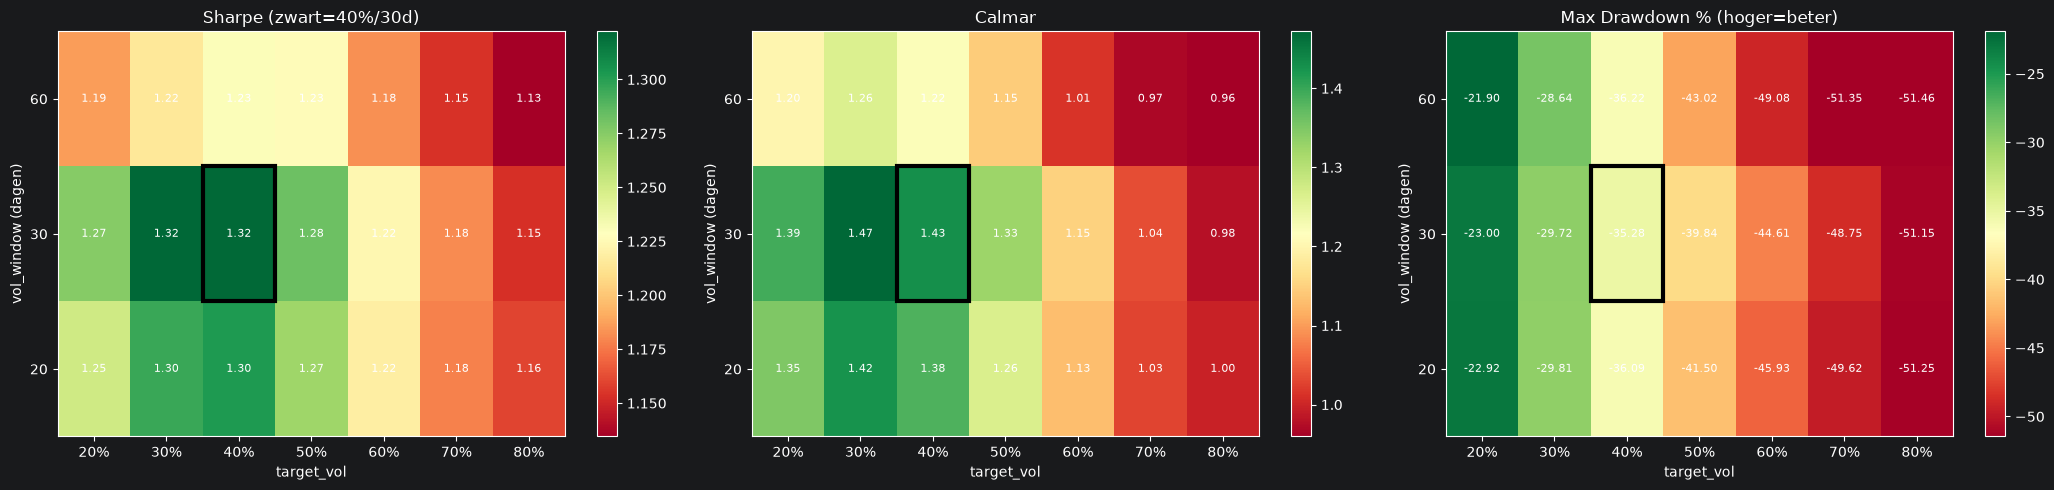

Per window, beste target op Calmar:
  window 20d -> target 30% (Calmar 1.42, Sharpe 1.30)
  window 30d -> target 30% (Calmar 1.47, Sharpe 1.32)
  window 60d -> target 30% (Calmar 1.26, Sharpe 1.22)


In [3]:
TV_GRID=[0.20,0.30,0.40,0.50,0.60,0.70,0.80]
W_GRID=[20,30,60]
rows=[]
for w in W_GRID:
    d=prepare(CSV, vol_win=w)
    for tv in TV_GRID:
        r=backtest(d, mode='voltarget', target_vol=tv)
        rows.append({'window':w,'target':tv,'sharpe':r['sharpe'],'calmar':r['calmar'],'mdd':r['mdd']*100,'cagr':r['cagr']*100})
sw=pd.DataFrame(rows)

def hm(df,metric,ax,title,cmap,hl=(30,0.40)):
    piv=df.pivot(index='window',columns='target',values=metric)
    im=ax.imshow(piv.values,aspect='auto',cmap=cmap,origin='lower')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f'{c:.0%}' for c in piv.columns])
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    ax.set_xlabel('target_vol'); ax.set_ylabel('vol_window (dagen)'); ax.set_title(title)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j,i,f'{piv.values[i,j]:.2f}',ha='center',va='center',fontsize=8)
    if hl[0] in list(piv.index) and hl[1] in list(piv.columns):
        yi=list(piv.index).index(hl[0]); xi=list(piv.columns).index(hl[1])
        ax.add_patch(patches.Rectangle((xi-0.5,yi-0.5),1,1,fill=False,edgecolor='black',lw=3))
    plt.colorbar(im,ax=ax)

fig,ax=plt.subplots(1,3,figsize=(21,5))
hm(sw,'sharpe',ax[0],'Sharpe (zwart=40%/30d)','RdYlGn')
hm(sw,'calmar',ax[1],'Calmar','RdYlGn')
hm(sw,'mdd',ax[2],'Max Drawdown % (hoger=beter)','RdYlGn')
plt.tight_layout(); plt.show()

print('Per window, beste target op Calmar:')
for w in W_GRID:
    best=sw[sw['window']==w].sort_values('calmar',ascending=False).iloc[0]
    print(f"  window {w:>2}d -> target {best['target']:.0%} (Calmar {best['calmar']:.2f}, Sharpe {best['sharpe']:.2f})")

In [4]:
# Plateau-check rond (window=30, target=40%)
def plateau(df, metric='calmar', win=30, tv=0.40):
    piv=df.pivot(index='window',columns='target',values=metric)
    ti=list(piv.index).index(win); ai=list(piv.columns).index(tv); chosen=piv.values[ti,ai]
    nb=[]
    for dt in(-1,0,1):
        for da in(-1,0,1):
            if dt==0 and da==0: continue
            nt,na=ti+dt,ai+da
            if 0<=nt<piv.shape[0] and 0<=na<piv.shape[1]: nb.append(piv.values[nt,na])
    nb=np.array(nb)
    print(f'--- Plateau-check "{metric}" rond (30d, 40%) ---')
    print(f'Gekozen: {chosen:.3f} | buren gem {nb.mean():.3f} (std {nb.std():.3f}) | buren min/max {nb.min():.3f}/{nb.max():.3f}')
    if nb.min()>0 and chosen<=nb.mean()+nb.std(): print('VERDICT: PLATEAU (robuust)')
    elif chosen>nb.mean()+2*nb.std() or nb.min()<=0: print('VERDICT: PIEK (voorzichtig)')
    else: print('VERDICT: tussenin')
plateau(sw,'sharpe'); print(); plateau(sw,'calmar')

--- Plateau-check "sharpe" rond (30d, 40%) ---
Gekozen: 1.321 | buren gem 1.268 (std 0.037) | buren min/max 1.215/1.322
VERDICT: tussenin

--- Plateau-check "calmar" rond (30d, 40%) ---
Gekozen: 1.428 | buren gem 1.313 (std 0.103) | buren min/max 1.146/1.472
VERDICT: tussenin


## 2. Train/test: lock op 2018-2022, draai op 2023-2026

In [5]:
d30=prepare(CSV, vol_win=30)
is_df=d30[d30['date']<=SPLIT].reset_index(drop=True)
oos_df=d30[d30['date']>SPLIT].reset_index(drop=True)

print('=== 2a. JOUW KEUZE (target 40%, window 30d) ===')
r_is=backtest(is_df, mode='voltarget', target_vol=0.40)
r_oos=backtest(oos_df, mode='voltarget', target_vol=0.40)
show('In-sample 2018-2022', r_is)
show('Out-sample 2023-2026', r_oos)
for k,l in [('sharpe','Sharpe'),('calmar','Calmar')]:
    ratio=r_oos[k]/r_is[k] if r_is[k] else float('nan')
    print(f'  {l} OOS/IS: {ratio*100:.0f}% ' + ('(gezond)' if (isinstance(ratio,float) and ratio>0.6) else '(zwak)'))

print('\n=== 2b. BESTE IS-TARGET, GELOCKED, OP OOS ===')
is_scan=[]
for tv in TV_GRID:
    is_scan.append((tv, backtest(is_df, mode='voltarget', target_vol=tv)['calmar']))
best_tv=max(is_scan,key=lambda x:x[1])[0]
print(f'Beste target op 2018-2022 (Calmar): {best_tv:.0%}')
show('Die target op IS', backtest(is_df, mode='voltarget', target_vol=best_tv))
show('Die target op OOS', backtest(oos_df, mode='voltarget', target_vol=best_tv))
print(f"Ligt IS-optimum ({best_tv:.0%}) dicht bij jouw keuze (40%)? {'JA' if abs(best_tv-0.40)<=0.1 else 'NEE -> verdacht'}")

=== 2a. JOUW KEUZE (target 40%, window 30d) ===
In-sample 2018-2022      CAGR  61.0% | Sharpe 1.42 | Calmar 1.73 | MDD  -35.3% | €10,409 | trades 24
Out-sample 2023-2026     CAGR  36.4% | Sharpe 1.17 | Calmar 1.15 | MDD  -31.8% | €2,906 | trades 16
  Sharpe OOS/IS: 82% (gezond)
  Calmar OOS/IS: 66% (gezond)

=== 2b. BESTE IS-TARGET, GELOCKED, OP OOS ===
Beste target op 2018-2022 (Calmar): 30%
Die target op IS         CAGR  53.9% | Sharpe 1.43 | Calmar 1.81 | MDD  -29.7% | €8,333 | trades 24
Die target op OOS        CAGR  30.4% | Sharpe 1.15 | Calmar 1.20 | MDD  -25.3% | €2,490 | trades 16
Ligt IS-optimum (30%) dicht bij jouw keuze (40%)? NEE -> verdacht


## Hoe lees je dit
**Groen licht:** heatmap toont een breed groen gebied rond (40%, 30d) i.p.v. een geisoleerd vakje; plateau-check zegt PLATEAU; OOS-Calmar >= ~60% van IS; IS-optimale target ligt dicht bij 40%.

**Rood licht:** (40%, 30d) is een piek tussen slechte buren; OOS halveert; IS-optimum springt naar 20% of 80%.

Als groen: dit was de laatste backtest-horde. Daarna echt paper-traden op nieuwe data — geen historische test meer, maar live meedraaien zonder geld.